In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
)

In [2]:
data = load_breast_cancer(as_frame=True)  # dataset loader
X = data.data
y = data.target  # 0/1 labels

df = X.copy()
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((426, 30), (143, 30))

In [5]:
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=500))]
)

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=500))])

In [6]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=500))])

In [7]:
proba = model.predict_proba(X_test)

proba[:5]

array([[3.10179769e-02, 9.68982023e-01],
       [9.99647982e-01, 3.52018216e-04],
       [4.40588468e-01, 5.59411532e-01],
       [6.10542466e-02, 9.38945753e-01],
       [8.24508132e-01, 1.75491868e-01]])

In [8]:
p_malignant = proba[:, 0]
p_benign = proba[:, 1]

p_malignant[:10]

array([3.10179769e-02, 9.99647982e-01, 4.40588468e-01, 6.10542466e-02,
       8.24508132e-01, 9.99999038e-01, 9.97238130e-01, 9.99239516e-01,
       9.99337681e-01, 9.09204364e-05])

In [9]:
threshold = 0.50

y_pred_custom = np.where(p_malignant >= threshold, 0, 1)  # 0 malignant, 1 benign
y_pred_custom[:20]

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])

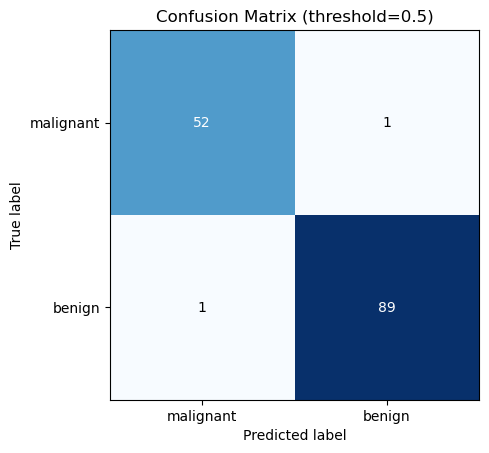

In [10]:
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues, colorbar=False)

thresh = cm.max() / 2
for t in disp.text_.ravel():
    v = float(t.get_text())
    t.set_color("white" if v > thresh else "black")

disp.ax_.set_title(f"Confusion Matrix (threshold={threshold})")
plt.show()

In [11]:
print(classification_report(y_test, y_pred_custom, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [12]:
auc = roc_auc_score((y_test == 0).astype(int), p_malignant)
auc

np.float64(0.9976939203354298)

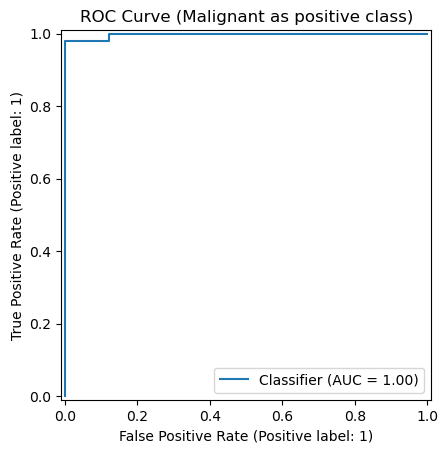

In [13]:
RocCurveDisplay.from_predictions((y_test == 0).astype(int), p_malignant)
plt.title("ROC Curve (Malignant as positive class)")
plt.show()

In [14]:
for threshold in [0.7, 0.5, 0.3]:
    y_pred_t = np.where(p_malignant >= threshold, 0, 1)
    cm = confusion_matrix(y_test, y_pred_t)
    print(f"\nThreshold = {threshold}")
    print(cm)


Threshold = 0.7
[[50  3]
 [ 0 90]]

Threshold = 0.5
[[52  1]
 [ 1 89]]

Threshold = 0.3
[[52  1]
 [ 6 84]]
